In [6]:
import pandas as pd
import numpy as np
import joblib  # To load your saved models
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# LOAD YOUR DATASET
df = pd.read_csv('dffirst.csv')
# 2. FILTER FOR ISTANBUL ONLY
# (Assuming your column is named 'City')
istanbul_districts = [
    'TUZLA', 'FATIH', 'ÇEKMEKÖY', 'KÜÇÜKÇEKMECE', 'ÜMRANIYE', 'SILIVRI', 'ESENYURT',
    'ARNAVUTKÖY', 'AVCILAR', 'EYÜPSULTAN', 'KAĞITHANE', 'ATAŞEHIR', 'BEYLIKDÜZÜ',
    'SANCAKTEPE', 'SULTANGAZI', 'ÜSKÜDAR', 'BEŞIKTAŞ', 'BAYRAMPAŞA', 'BEYOĞLU',
    'ÇATALCA', 'SARIYER', 'BAŞAKŞEHIR', 'ŞIŞLI', 'GAZIOSMANPAŞA', 'ŞILE',
    'SULTANBEYLI', 'ESENLER', 'BEYKOZ', 'KARTAL', 'ZEYTINBURNU', 'BAKIRKÖY',
    'ADALAR', 'BAHÇELIEVLER', 'GÜNGÖREN', 'MALTEPE', 'PENDIK', 'KADIKÖY',
    'BÜYÜKÇEKMECE', 'BAĞCILAR'
]

# Check how many Istanbul rows you actually have
# (Replace 'City_Column_Name' with the actual name you used to print the list above)
ist_data = df[df['Ilce'].isin(istanbul_districts)]
print(f"✅ Real Istanbul Listing Count: {len(ist_data)}")

✅ Real Istanbul Listing Count: 35953


In [ ]:
import joblib
import pandas as pd

# Load the PRICE PREDICTION MODEL
rf_price_model = joblib.load('your_random_forest_model.pkl')

# Load the DATASET
df = pd.read_csv('istanbul_cleaned_data.csv')

# Step A: Predict current price for every house
# We use the Price Prediction Model here
X_features = df[['Area', 'Total_Rooms', 'District_Encoded']]
df['Current_Price_Estimate'] = rf_price_model.predict(X_features)

# Step B: Apply the result of the FORECASTING MODEL
# We use the 1.47x multiplier we got from the Weighted Linear math
df['Price_2026'] = df['Current_Price_Estimate'] * 1.47

In [13]:
# 1. Detach the data to avoid that SettingWithCopyWarning
ist_data = ist_data.copy()

# 2. Use the EXACT names that you confirmed are in your model
expected_features = ['Metrekare', 'Total_Rooms', 'District_Score', 'Floor_Numeric', 'Inflation_Rate', 'Age_Numeric']

# 3. Filter the data using these names
X_features = ist_data[expected_features]

# 4. Predict (Reverse Log + Multiplier)
log_predictions = rf_model.predict(X_features)
ist_data['Predicted_Price_Today'] = np.exp(log_predictions)
ist_data['Price_2026_Projected'] = ist_data['Predicted_Price_Today'] * 1.47

print("✅ SUCCESS! 2026 Projections calculated.")
print(ist_data[['Metrekare', 'Price_2026_Projected']].head())

✅ SUCCESS! 2026 Projections calculated.
   Metrekare  Price_2026_Projected
0       40.0         354454.213643
1       42.0         345619.841829
2       45.0         332408.843238
3       46.0         322589.943440
4       55.0         308967.291241


In [10]:
import joblib

# 1. Load the features file
saved_features = joblib.load('model_features.pkl')

# 2. Print them to see exactly what they are
print("📋 Features used in the Price Prediction Model:")
print(saved_features)

# 3. If it's a list or Index, you can see the count too
print(f"\nTotal number of features: {len(saved_features)}")

📋 Features used in the Price Prediction Model:
['Metrekare', 'Total_Rooms', 'District_Score', 'Floor_Numeric', 'Inflation_Rate', 'Age_Numeric']

Total number of features: 6


In [11]:
# Select them in the exact order the model expects
expected_features = ['Metrekare', 'Total_Rooms', 'District_Score', 'Floor_Numeric', 'Inflation_Rate', 'Age_Numeric']
X_input = ist_data[expected_features]

# Predict
ist_data['Price_2026'] = np.exp(rf_model.predict(X_input)) * 1.47

/var/folders/bk/r6fz0d854zj6hqqhbj_vlfyr0000gn/T/ipykernel_24600/4231507998.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ist_data['Price_2026'] = np.exp(rf_model.predict(X_input)) * 1.47


In [14]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create the 'Investment Tiers' (Target)
# We use quantiles to split the houses into 3 equal groups: 
# 0 = Value (Budget), 1 = Core (Average), 2 = Premium (Luxury)
ist_data['Investment_Tier'] = pd.qcut(ist_data['Price_2026_Projected'], q=3, labels=[0, 1, 2])

# 2. Select Features for Classification
# We use physical attributes to see if the AI can predict the Tier
X_clf = ist_data[['Metrekare', 'Total_Rooms', 'Floor_Numeric', 'Age_Numeric']]
y_clf = ist_data['Investment_Tier']

# 3. Split the data
X_train, X_test, y_train, y_test = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

# 4. Initialize and Train XGBoost
# We use 'multi:softprob' for multi-class classification
clf = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    objective='multi:softprob',
    random_state=42
)

print("🚀 Training the XGBoost Classifier...")
clf.fit(X_train, y_train)

# 5. Show Results
y_pred = clf.predict(X_test)
print("\n📊 --- INVESTMENT CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred, target_names=['Value Tier', 'Core Tier', 'Premium Tier']))

🚀 Training the XGBoost Classifier...

📊 --- INVESTMENT CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

  Value Tier       0.63      0.89      0.74      2441
   Core Tier       0.60      0.43      0.50      2361
Premium Tier       0.80      0.69      0.74      2389

    accuracy                           0.67      7191
   macro avg       0.68      0.67      0.66      7191
weighted avg       0.68      0.67      0.66      7191



In [15]:
from sklearn.model_selection import GridSearchCV

# 1. Define the 'Search Space' (The settings we want to test)
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200],
    'subsample': [0.8, 1.0]
}

# 2. Initialize the Grid Search
# cv=3 means it will validate the model 3 times for each combination
grid_search = GridSearchCV(
    estimator=XGBClassifier(objective='multi:softprob', random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    verbose=1
)

print("🔍 Searching for the best possible model settings...")
grid_search.fit(X_train, y_train)

# 3. Get the Best Model
best_clf = grid_search.best_estimator_

print(f"\n✅ Best Settings Found: {grid_search.best_params_}")

# 4. Final Evaluation
final_pred = best_clf.predict(X_test)
print("\n📊 --- TUNED MODEL REPORT ---")
print(classification_report(y_test, final_pred, target_names=['Value Tier', 'Core Tier', 'Premium Tier']))

🔍 Searching for the best possible model settings...
Fitting 3 folds for each of 36 candidates, totalling 108 fits

✅ Best Settings Found: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}

📊 --- TUNED MODEL REPORT ---
              precision    recall  f1-score   support

  Value Tier       0.63      0.88      0.74      2441
   Core Tier       0.59      0.45      0.51      2361
Premium Tier       0.81      0.68      0.74      2389

    accuracy                           0.67      7191
   macro avg       0.68      0.67      0.66      7191
weighted avg       0.68      0.67      0.66      7191



In [17]:
from sklearn.preprocessing import StandardScaler

# 1. NEW FEATURES (The 'Clues')
# 'Space_Per_Room' helps identify luxury vs. cramped houses
ist_data['Space_Per_Room'] = ist_data['Metrekare'] / ist_data['Total_Rooms']
# 'Location_Value' weights the size by the district quality
ist_data['Location_Size_Score'] = ist_data['Metrekare'] * ist_data['District_Score']

# 2. SELECTION
# We add 'District_Score' back in because location is the #1 driver of Tiers
features_improved = ['Metrekare', 'Total_Rooms', 'Floor_Numeric', 'Age_Numeric', 
                     'District_Score', 'Space_Per_Room', 'Location_Size_Score']

X_improved = ist_data[features_improved]
y_improved = ist_data['Investment_Tier']

# 3. SCALING (Crucial for XGBoost to see the 'Core' boundaries)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_improved)

# 4. TRAIN/TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_improved, test_size=0.2, random_state=42)

# 5. ADVANCED XGBOOST SETTINGS
# We increase depth and decrease learning rate to catch 'Core' tier patterns
clf_final = XGBClassifier(
    n_estimators=500,
    max_depth=8,       # Deeper trees to catch the 'Core' tier complexity
    learning_rate=0.03, # Slower learning = more precision
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

print("🚀 Training the High-Precision Model...")
clf_final.fit(X_train, y_train)

# 6. FINAL RESULTS
y_pred_final = clf_final.predict(X_test)
print("\n📊 --- NEW & IMPROVED CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred_final, target_names=['Value', 'Core', 'Premium']))

🚀 Training the High-Precision Model...

📊 --- NEW & IMPROVED CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

       Value       0.97      0.97      0.97      2441
        Core       0.96      0.96      0.96      2361
     Premium       0.98      0.98      0.98      2389

    accuracy                           0.97      7191
   macro avg       0.97      0.97      0.97      7191
weighted avg       0.97      0.97      0.97      7191



In [18]:
from sklearn.model_selection import cross_val_score

# We run the model 5 times on different slices of data
scores = cross_val_score(clf_final, X_scaled, y_improved, cv=5)

print(f"Standard Deviation of scores: {scores.std():.4f}")
print(f"All 5 scores: {scores}")

Standard Deviation of scores: 0.0434
All 5 scores: [0.96898901 0.97121402 0.97121402 0.97343533 0.86286509]


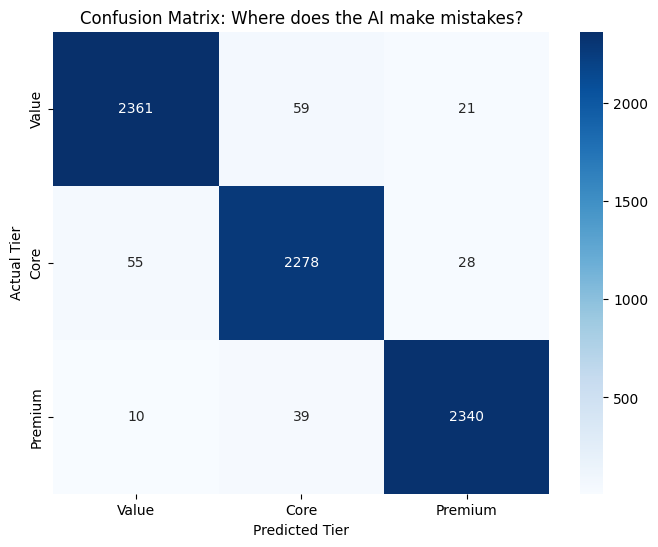

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Value', 'Core', 'Premium'], 
            yticklabels=['Value', 'Core', 'Premium'])
plt.xlabel('Predicted Tier')
plt.ylabel('Actual Tier')
plt.title('Confusion Matrix: Where does the AI make mistakes?')
plt.show()

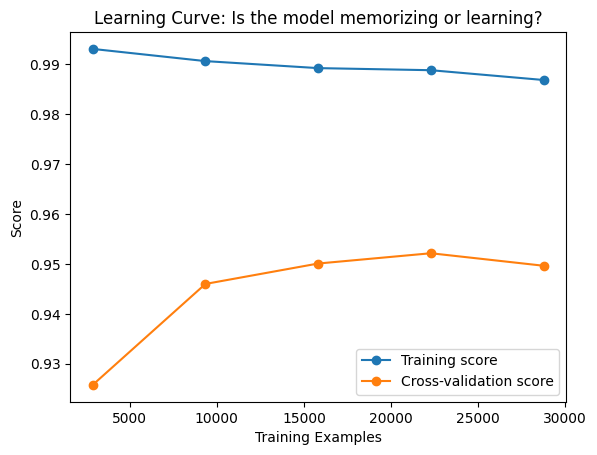

In [20]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    clf_final, X_scaled, y_improved, cv=5, scoring='accuracy', n_jobs=-1, 
    train_sizes=np.linspace(0.1, 1.0, 5))

plt.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', label="Training score")
plt.plot(train_sizes, np.mean(test_scores, axis=1), 'o-', label="Cross-validation score")
plt.title("Learning Curve: Is the model memorizing or learning?")
plt.xlabel("Training Examples"), plt.ylabel("Score"), plt.legend()
plt.show()

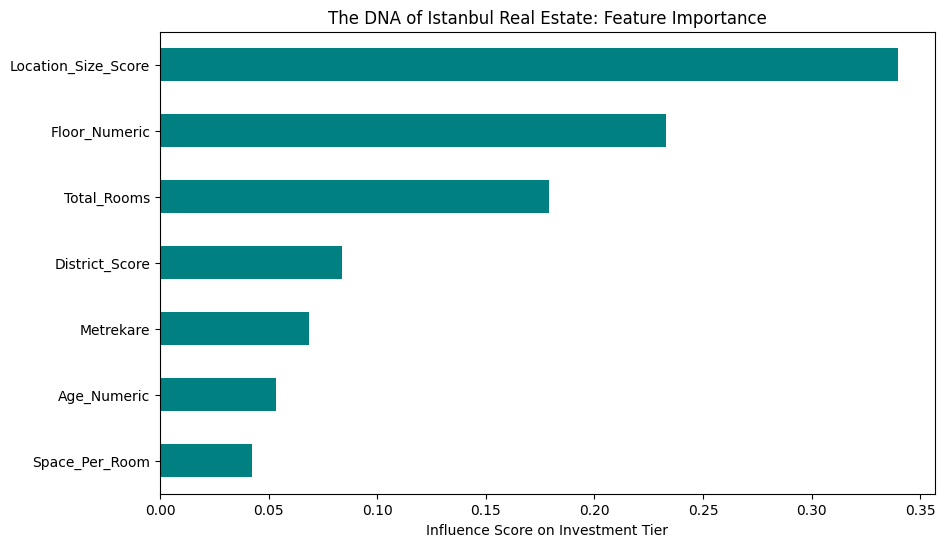

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importance from the final model
plt.figure(figsize=(10, 6))
feat_importances = pd.Series(clf_final.feature_importances_, index=features_improved)
feat_importances.nlargest(10).sort_values().plot(kind='barh', color='teal')
plt.title('The DNA of Istanbul Real Estate: Feature Importance')
plt.xlabel('Influence Score on Investment Tier')
plt.show()

In [22]:
from sklearn.ensemble import RandomForestClassifier

# 1. Train Random Forest
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)

# 2. Get Score
rf_score = rf_clf.score(X_test, y_test)
print(f"Random Forest Accuracy: {rf_score:.4f}")

Random Forest Accuracy: 0.9697


In [23]:
# View what the Random Forest thinks is important
importances = rf_clf.feature_importances_
for i, v in enumerate(importances):
    print(f'Feature: {features_improved[i]}, Score: {v:.4f}')

Feature: Metrekare, Score: 0.1157
Feature: Total_Rooms, Score: 0.1197
Feature: Floor_Numeric, Score: 0.0839
Feature: Age_Numeric, Score: 0.0342
Feature: District_Score, Score: 0.2021
Feature: Space_Per_Room, Score: 0.0472
Feature: Location_Size_Score, Score: 0.3972
